<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [1]:
!pip install gensim keras tensorflow plotly

In [2]:
import pandas as pd
from gensim.models import Word2Vec

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [3]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2026k  100 2026k    0     0  5517k      0 --:--:-- --:--:-- --:--:-- 5521k


In [4]:
# Posibles bandas
os.listdir("./songs_dataset/")

['prince.txt',
 'dickinson.txt',
 'notorious-big.txt',
 'beatles.txt',
 'bob-dylan.txt',
 'bjork.txt',
 'johnny-cash.txt',
 'disney.txt',
 'janisjoplin.txt',
 'kanye.txt',
 'bob-marley.txt',
 'leonard-cohen.txt',
 'ludacris.txt',
 'adele.txt',
 'alicia-keys.txt',
 'joni-mitchell.txt',
 'amy-winehouse.txt',
 'lorde.txt',
 'rihanna.txt',
 'Kanye_West.txt',
 'nirvana.txt',
 'cake.txt',
 'bieber.txt',
 'notorious_big.txt',
 'missy-elliott.txt',
 'dolly-parton.txt',
 'jimi-hendrix.txt',
 'michael-jackson.txt',
 'al-green.txt',
 'lil-wayne.txt',
 'lady-gaga.txt',
 'lin-manuel-miranda.txt',
 'nursery_rhymes.txt',
 'dj-khaled.txt',
 'radiohead.txt',
 'patti-smith.txt',
 'blink-182.txt',
 'Lil_Wayne.txt',
 'dr-seuss.txt',
 'r-kelly.txt',
 'drake.txt',
 'britney-spears.txt',
 'bruce-springsteen.txt',
 'nicki-minaj.txt',
 'kanye-west.txt',
 'paul-simon.txt',
 'nickelback.txt',
 'eminem.txt',
 'bruno-mars.txt']

In [5]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/var/folders/xz/7wg9f3097hz464l8t67l1cdh0000gn/T/ipykernel_61661/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [6]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [7]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [8]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [9]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [10]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [11]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [12]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [13]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [14]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.28125
Loss after epoch 1: 65966.59375
Loss after epoch 2: 65934.921875
Loss after epoch 3: 65718.390625
Loss after epoch 4: 63875.125
Loss after epoch 5: 64160.90625
Loss after epoch 6: 64080.375
Loss after epoch 7: 64814.96875
Loss after epoch 8: 62632.6875
Loss after epoch 9: 60452.6875
Loss after epoch 10: 59840.125
Loss after epoch 11: 58884.0625
Loss after epoch 12: 57716.0625
Loss after epoch 13: 56493.875
Loss after epoch 14: 55817.5
Loss after epoch 15: 55842.9375
Loss after epoch 16: 51722.625
Loss after epoch 17: 49858.125
Loss after epoch 18: 49592.0
Loss after epoch 19: 48960.375


(156986, 287740)

### 4 - Ensayar

In [15]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954241275787354),
 ('sleep', 0.8665648102760315),
 ('help', 0.8439377546310425),
 ('cry', 0.8351278305053711),
 ('not', 0.8309565782546997),
 ('try', 0.8276928067207336),
 ('peace', 0.8144847750663757),
 ('little', 0.8140541911125183),
 ('twist', 0.8123903870582581),
 ('seems', 0.8079550862312317)]

In [16]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.22872473299503326),
 ('four', -0.2330225110054016),
 ('five', -0.23746483027935028),
 ('six', -0.23784109950065613),
 ('bang', -0.24832148849964142),
 ('our', -0.25538331270217896),
 ('day', -0.2689809501171112),
 ('going', -0.26920315623283386),
 ('here', -0.2699021100997925),
 ('three', -0.28389549255371094)]

In [17]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813734292984009),
 ('three', 0.9745770692825317),
 ('six', 0.9710827469825745),
 ('seven', 0.9584391713142395),
 ('two', 0.9517229795455933),
 ('sixty', 0.8990437388420105),
 ('one', 0.7951188087463379),
 ('crying', 0.7946332693099976),
 ('us', 0.7740050554275513),
 ("i'm", 0.7508416175842285)]

In [18]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434012770652771),
 ('buy', 0.9397005438804626),
 ('much', 0.9033158421516418),
 ('just', 0.8509080410003662),
 ('hide', 0.8355337381362915)]

In [19]:
# Ensayar con una palabra que no está en el vocabulario:
# w2v_model.wv.most_similar(negative=["diedaa"])

In [20]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138405  0.058809   -0.06370325  0.02445593 -0.20152055 -0.18612228
 -0.15284562  0.45487782 -0.04217936  0.03536211  0.13657948 -0.18519847
 -0.18126771  0.2214913  -0.3038063  -0.23970455  0.07094643 -0.05679133
 -0.05166036 -0.23843044 -0.08529771  0.195644   -0.07679128  0.03796851
  0.07516617 -0.04825819  0.07379003  0.10396867  0.00737886 -0.22764948
 -0.04567026  0.12936729  0.27786148  0.19387393 -0.13509513  0.20856662
  0.40916505 -0.00386539 -0.10631859 -0.09057057  0.02400651 -0.08005195
  0.1340099   0.08833113 -0.01894911  0.08592594 -0.15906131  0.10259284
  0.14459819 -0.12092229 -0.279187   -0.0406201   0.11382356  0.31366625
 -0.07409906  0.13977523  0.22791535  0.13209976 -0.01811203  0.0977301
  0.09249622 -0.14872141 -0.16348357 -0.13202755 -0.09834751  0.02714126
  0.16531599  0.26052776 -0.03259096 -0.02894498  0.11620875 -0.06974296
  0.09563834 -0.15276456  0.22071241  0.1599668   0.15890227 -0.04711496
 -0.12555523 -0.03993179 -0.10795247  0.01879167  0.

In [21]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 0.9999999403953552),
 ('babe', 0.9085148572921753),
 ('someone', 0.8886125683784485),
 ('need', 0.8827983736991882),
 ('nothing', 0.8740253448486328),
 ("didn't", 0.8638355135917664),
 ("there's", 0.8526684641838074),
 ('you', 0.8456717729568481),
 ('feed', 0.8445045351982117),
 ('somebody', 0.8362783193588257)]

In [22]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085148572921753),
 ('someone', 0.8886125683784485),
 ('need', 0.8827983736991882),
 ('nothing', 0.8740253448486328),
 ("didn't", 0.8638355135917664),
 ("there's", 0.8526684641838074),
 ('you', 0.8456718921661377),
 ('feed', 0.8445045351982117),
 ('somebody', 0.8362783193588257),
 ('buy', 0.8351733088493347)]

### 5 - Visualizar agrupación de vectores

In [23]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [24]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

<!doctype html>

In [25]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

<!doctype html>

In [26]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

---

# Desafío 2

Para el siguiente desafio se utiliza la novela [The Adventures of Sherlock Holmes](https://www.gutenberg.org/ebooks/1661) de Arthur Conan Doyle descargada de [Project Gutenberg](https://www.gutenberg.org/). En particular descargamos la [version en texto plano](https://www.gutenberg.org/cache/epub/1661/pg1661.txt) por la facilidad de descargar y empezar a utilizar.

Para resolver la consigna se reutiliza el mismo pipeline visto en clase:
- tokenización con `text_to_word_sequence`, 
- `Word2Vec` skip-gram de Gensim con el `callback` de loss
-  `TSNE` + `plotly` para visualizar 

### Punto 1

**Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio.**

Elegimos The Adventures of Sherlock Holmes por varias razones:

- Es prosa narrativa con dialogos. Esto nos permite ver si el mismo modelo captura relaciones en un tipo de texto distinto.
- Tiene un vocabulario tematico marcado: 
    - Personajes (Holmes, Watson, Lestrade)
    - Lugares de Londres (Baker Street)
    - El mundo policial (police, inspector, crime)
    - Objetos cotidianos de la época (letter, telegram, cab) 
    - y expresiones de tiempo
    
    lo que debería generar grupos de palabras interpretables.

In [27]:
import os

SHERLOCK_URL = "https://www.gutenberg.org/cache/epub/1661/pg1661.txt"
SHERLOCK_FILE = "sherlock_holmes.txt"

if os.access(SHERLOCK_FILE, os.F_OK) is False:
    !curl -sL {SHERLOCK_URL} -o {SHERLOCK_FILE}
else:
    print("-- El corpus ya se encuentra descargado --\n\n")

with open(SHERLOCK_FILE, encoding="utf-8") as fp:
    sherlock_holmes_txt = fp.read()

print(sherlock_holmes_txt[:600])

The Project Gutenberg eBook of The Adventures of Sherlock Holmes
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: The Adventures of Sherlock Holmes

Author: Arthur Conan Doyle


        
Releas


El archivo de Gutenberg tiene tres particularidades que hay que resolver antes de tokenizar:

1. Trae un **encabezado y un pie de licencia** que no son parte de la novela. El texto útil está delimitado por las marcas `*** START OF THE PROJECT GUTENBERG EBOOK ...` y `*** END OF THE PROJECT GUTENBERG EBOOK ...`.
2. Usa **puntuación tipográfica** (comillas `“ ” ‘ ’`, guiones largos `—`) y marca las itálicas con `_`. `text_to_word_sequence` solo filtra puntuación ASCII, así que si no la normalizamos quedarían tokens como `“the` o `holmes—`.
3. El texto está **cortado a ~70 columnas**: un salto de línea no marca el fin de una oración, sino que los párrafos se separan por una línea en blanco. Por eso primero reconstruimos los párrafos y después los separamos en oraciones usando `. ! ?` como delimitadores.



Tomando como referencia este mismo Notebook, armamos un DataFrame `sh_df` con una oración por fila.

In [28]:
import pandas as pd
import re

# 1) Quedarnos solo con el cuerpo de la novela
inicio = sherlock_holmes_txt.index("*** START OF THE PROJECT GUTENBERG EBOOK THE ADVENTURES OF SHERLOCK HOLMES ***")
inicio = sherlock_holmes_txt.index("\n", inicio) + 1
fin = sherlock_holmes_txt.index("*** END OF THE PROJECT GUTENBERG EBOOK THE ADVENTURES OF SHERLOCK HOLMES ***")

# Texto entre "*** START OF THE PROJECT GUTENBERG EBOOK THE ADVENTURES OF SHERLOCK HOLMES ***" hasta 
book_content = sherlock_holmes_txt[inicio:fin].replace("\r\n", "\n")

# 2) Normalizar puntuación tipográfica que text_to_word_sequence no filtra
for viejo, nuevo in {"“": '"', "”": '"', "‘": "'", "’": "'", "—": " ", "_": " "}.items():
    book_content = book_content.replace(viejo, nuevo)

# 3) Reconstruir parrafos (separados por línea en blanco) y partirlos en oraciones
sh_paragraphs = [re.sub(r"\s+", " ", p).strip() for p in re.split(r"\n\s*\n", book_content)]
sh_paragraphs = [p for p in sh_paragraphs if p]

sh_sentences = [o for p in sh_paragraphs for o in re.split(r"(?<=[.!?])\s+", p) if o]

sh_df = pd.DataFrame(sh_sentences, columns=['sentence'])
print("Cantidad de parrafos:", len(sh_paragraphs))
print("Cantidad de documentos (oraciones):", sh_df.shape[0])

sh_df.iloc[10:25]

Cantidad de parrafos: 2546
Cantidad de documentos (oraciones): 6986


,sentence
10,The Adventure of the Blue Carbuncle VIII.
11,The Adventure of the Speckled Band IX.
12,The Adventure of the Engineer's Thumb X.
13,The Adventure of the Noble Bachelor XI.
14,The Adventure of the Beryl Coronet XII.
15,The Adventure of the Copper Beeches
16,I.
17,A SCANDAL IN BOHEMIA
18,I.
19,To Sherlock Holmes she is always the woman.


Tokenizamos usando `text_to_word_sequence` de [Tensorflow](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/text_to_word_sequence). 

El mismo pasa a minusculas y elimina la puntuación ASCII. Agregamos dos detalles:

- Como convertimos las comillas simples tipográficas a `'`, algunos tokens quedan con un apóstrofe al inicio o al final (`'i`, `him'`). Los recortamos con `strip("'")` para no duplicar palabras, conservando las contracciones (`don't`, `o'clock`).
- Descartamos las "oraciones" de un solo token (por ejemplo: titulos de capitulo como `I.`, `II.`, o exclamaciones sueltas) porque no aportan contexto para skip-gram.

In [29]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

def tokenizar(texto):
    tokens = [t.strip("'") for t in text_to_word_sequence(texto)]
    return [t for t in tokens if t]

sh_tokens = []
for _, row in sh_df.iterrows():
    tokens = tokenizar(row['sentence'])
    if len(tokens) > 1:
        sh_tokens.append(tokens)

print("Documentos con al menos 2 tokens:", len(sh_tokens))
print("Cantidad total de tokens:", sum(len(t) for t in sh_tokens))
print("Cantidad de palabras distintas:", len({w for t in sh_tokens for w in t}))
sh_tokens[10:13]

Documentos con al menos 2 tokens: 6672
Cantidad total de tokens: 105128
Cantidad de palabras distintas: 8003


[['the', 'adventure', 'of', 'the', "engineer's", 'thumb', 'x'],
 ['the', 'adventure', 'of', 'the', 'noble', 'bachelor', 'xi'],
 ['the', 'adventure', 'of', 'the', 'beryl', 'coronet', 'xii']]

El corpus tiene unos 105.000 tokens repartidos en ~6.700 oraciones, es decir, unas 15 palabras por documento. 

Es unas 10 veces más grande que el corpus de los Beatles (1.846 documentos), aunque sigue siendo **muy chico** para word2vec, que suele entrenarse con millones de tokens. Por eso esperamos vecinos razonables para las palabras frecuentes y ruido para las poco frecuentes.

Configuramos el modelo [Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html) partiendo de los hiperparametros utilizados previamente en este Notebook y ajustando los que dependen del tipo de texto:

| Parámetro | Clase (Beatles) | Sherlock Holmes | Motivo |
|---|---|---|---|
| `window` | 2 | **5** | Las oraciones de prosa son más largas que los versos |
| `seed` / `workers` | – / 1 | 42 / 1 | Hacemos que el entrenamiento sea reproducible |

In [30]:
from gensim.models import Word2Vec

sh_model = Word2Vec(min_count=5,
                    window=5,
                    vector_size=300,
                    negative=20,
                    workers=1,
                    sg=1,
                    seed=42)

sh_model.build_vocab(sh_tokens)

print("Cantidad de docs en el corpus:", sh_model.corpus_count)
print("Cantidad de words distintas en el vocabulario (min_count=5):", len(sh_model.wv.index_to_key))

Cantidad de docs en el corpus: 6672
Cantidad de words distintas en el vocabulario (min_count=5): 2056


De las 6.672 palabras distintas del libro, solo 2.056 superan el `min_count=5`; el resto son palabras muy poco frecuentes (nombres propios secundarios, palabras raras) que igualmente no podríamos representar bien.

In [31]:
sh_model.train(sh_tokens,
               total_examples=sh_model.corpus_count,
               epochs=20,
               compute_loss=True,
               callbacks=[callback()])

Loss after epoch 0: 1305600.25


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Loss after epoch 1: 998399.5
Loss after epoch 2: 894544.0
Loss after epoch 3: 888809.5
Loss after epoch 4: 837693.75
Loss after epoch 5: 827021.5
Loss after epoch 6: 825032.5
Loss after epoch 7: 822112.5
Loss after epoch 8: 822151.0
Loss after epoch 9: 797175.5
Loss after epoch 10: 790778.0
Loss after epoch 11: 788338.0
Loss after epoch 12: 782154.0
Loss after epoch 13: 782214.0
Loss after epoch 14: 775465.0
Loss after epoch 15: 773882.0
Loss after epoch 16: 768423.0
Loss after epoch 17: 770420.0
Loss after epoch 18: 771181.0
Loss after epoch 19: 770029.0


(1264482, 2102560)

Sobre el loss, vemos que cae fuerte en las primeras 3 epochs (pasa de ~1,3M a ~0,9M) y después baja de forma lenta y sostenida hasta estabilizarse alrededor de ~0,77M en las últimas 5 epochs, donde ya empieza a oscilar.

> Nota: recordar que el `callback` imprime la diferencia entre epochs porque Gensim acumula el loss

### Punto 2

**Elegir términos de interés y buscar términos más similares y menos similares.**

Elegimos terminos del libro para ver qué tipo de relacion captura el modelo en cada caso:

- Personajes: `holmes`, `watson`
- Lugares: `street`
- Objetos / escenario: `door`, `letter`
- Tiempo: `morning`
- Un termino ligado a una sola historia: `king` (Capitulo I. A Scandal in Bohemia).

Definimos una función auxiliar que muestra lado a lado los 10 terminos mas similares `most_similar(positive=[palabra])` y los 10 menos similares `most_similar(negative=[palabra])` ordenado por similitud coseno con el vector opuesto.

> Para poder analizar a profundidad la relacion con las palabras mas similares se utilizo Claude Code y se le pidio que lea el texto original y resalte en donde se hace mencion de las palabras similares.

In [32]:
def similares(model, palabra, topn=10):
    mas = model.wv.most_similar(positive=[palabra], topn=topn)
    menos = model.wv.most_similar(negative=[palabra], topn=topn)
    print(f"'{palabra}' aparece {model.wv.get_vecattr(palabra, 'count')} veces en el corpus")
    return pd.DataFrame({
        "mas_similar": [w for w, _ in mas],
        "similitud": [round(float(s), 3) for _, s in mas],
        "menos_similar": [w for w, _ in menos],
        "similitud ": [round(float(s), 3) for _, s in menos],
    })

In [33]:
similares(sh_model, "holmes")

'holmes' aparece 441 veces en el corpus


,mas_similar,similitud,menos_similar,similitud
0,jones,0.624,only,-0.031
1,staggered,0.604,save,-0.049
2,jabez,0.602,carried,-0.074
3,heartily,0.592,place,-0.098
4,tut,0.585,within,-0.100
5,lestrade,0.585,every,-0.104
6,sherlock,0.583,discovered,-0.108
7,wilson,0.575,having,-0.111
8,hum,0.571,could,-0.116
9,bradstreet,0.570,horrible,-0.117


`holmes` es la palabra de contenido más frecuente del libro y su vecino más cercano es, como era de esperar, `sherlock`.

Los demas vecinos se entienden como adverbios o adjetivos al rededor del personaje principal `sherlock holmes`. Por ejemplo: `"Tut! tut!" cried Sherlock Holmes`

In [34]:
similares(sh_model, "watson")

'watson' aparece 79 veces en el corpus


,mas_similar,similitud,menos_similar,similitud
0,doctor,0.736,iron,-0.062
1,prison,0.709,among,-0.069
2,scoundrel,0.688,by,-0.070
3,share,0.682,shining,-0.077
4,madam,0.669,grey,-0.097
5,ah,0.667,lip,-0.110
6,murmured,0.661,shade,-0.114
7,stop,0.660,protruding,-0.116
8,patient,0.657,coloured,-0.120
9,gasped,0.657,boscombe,-0.121


`watson` aparece 5 veces menos que `holmes` y casi siempre como **vocativo dentro de un diálogo** (*"Ah, Watson"*, *"thank you, Watson"*, *"you see, Watson"*). Eso explica que sus vecinos sean palabras de diálogo dirigidas a alguien: `you`, `ah`, `thank`, `madam`, `murmured`. 

También aparecen `doctor` y `patient`, que reflejan su profesión.

Vecinos como `prison` o `scoundrel` las interpretamos como ruido. Son palabras poco frecuentes que por azar comparten alguna oración con `watson`

In [35]:
similares(sh_model, "street")

'street' aparece 83 veces en el corpus


,mas_similar,similitud,menos_similar,similitud
0,leadenhall,0.764,might,-0.057
1,park,0.737,influence,-0.066
2,baker,0.727,whom,-0.071
3,lodgings,0.703,advice,-0.083
4,henry,0.697,should,-0.085
5,precisely,0.695,would,-0.085
6,victoria,0.678,those,-0.087
7,hansom,0.670,all,-0.092
8,waterloo,0.651,such,-0.094
9,bow,0.639,own,-0.094


Todos los vecinos principales son nombres de calles y lugares de Londres que en el libro preceden a `street` o aparecen en direcciones. Por ejemplo `baker` (Baker Street), `leadenhall` (Leadenhall Street), `victoria` (Victoria Street), `bow` (Bow Street), etc.

El modelo aprendió la construcción `<Nombre> Street` a partir de la co-ocurrencia, sin ninguna información externa. 

`precisely`, `park`, etc se cuelan porque aparece en frases de citas con hora y dirección ("at Baker Street precisely at...").

In [36]:
similares(sh_model, "door")

'door' aparece 144 veces en el corpus


,mas_similar,similitud,menos_similar,similitud
0,stairs,0.649,most,-0.027
1,bureau,0.639,set,-0.061
2,window,0.632,their,-0.067
3,hall,0.627,any,-0.073
4,crowd,0.621,every,-0.074
5,key,0.615,or,-0.077
6,dashed,0.611,considerable,-0.081
7,bushes,0.611,over,-0.081
8,panel,0.611,take,-0.082
9,unlocked,0.606,extraordinary,-0.082


Para `door` los vecinos forman un campo semántico muy coherente:

- Partes de la casa: `panel`, `stairs`, `hall`, `passage`, `hole`
- Acciones que se hacen con una puerta: `unlocked`, `locked`, `closed`, `opened`, `dashed`

Es un buen ejemplo de que con una palabra frecuente (144 apariciones) y contextos consistentes, incluso un corpus chico alcanza para obtener vecinos con sentido.

In [37]:
similares(sh_model, "letter")

'letter' aparece 30 veces en el corpus


,mas_similar,similitud,menos_similar,similitud
0,telegram,0.727,more,-0.061
1,uncle,0.707,features,-0.102
2,k,0.706,pale,-0.108
3,pondicherry,0.704,than,-0.129
4,received,0.694,woman,-0.132
5,paddington,0.692,figure,-0.136
6,march,0.681,any,-0.137
7,tossed,0.673,whose,-0.138
8,supply,0.672,words,-0.139
9,dundee,0.670,dying,-0.140


`letter` se agrupa con el vocabulario de la correspondencia: `telegram`, `received`, `post`, `march` (mes de la fecha de las cartas). 

Los vecinos `k`, `pondicherry` y `savannah` vienen de *The Five Orange Pips*, donde las cartas amenazantes llegan con matasellos de Pondicherry y Savannah y firmadas "K. K. K.". De nuevo el modelo mezcla relaciones generales (carta ~ telegrama ~ recibir) con detalles específicos de la trama.

In [38]:
similares(sh_model, "morning")

'morning' aparece 102 veces en el corpus


,mas_similar,similitud,menos_similar,similitud
0,evening,0.648,than,-0.033
1,afternoon,0.642,hair,-0.095
2,eleven,0.638,sent,-0.103
3,slept,0.616,up,-0.106
4,yesterday,0.615,into,-0.115
5,train,0.610,its,-0.118
6,early,0.607,without,-0.124
7,o'clock,0.605,face,-0.128
8,ceremony,0.604,hardly,-0.128
9,monday,0.597,appearance,-0.129


`morning` se relaciona con otras expresiones de tiempo: `evening`, `afternoon`, `yesterday`, `early`, `eleven`, `o'clock`, y con acciones asociadas al momento del día (`slept`, `train`). 

Notamos que `evening` y `afternoon` son casi "antónimos" de `morning`; sin embargo, son de los más similares. Word2vec captura que cumplen la misma función en la oración ("at eleven in the morning/evening"), no su significado opuesto.

In [39]:
similares(sh_model, "king")

'king' aparece 25 veces en el corpus


,mas_similar,similitud,menos_similar,similitud
0,bohemia,0.756,seemed,-0.027
1,county,0.693,might,-0.118
2,photograph,0.678,were,-0.122
3,adler,0.673,sat,-0.122
4,deed,0.672,features,-0.130
5,duncan,0.671,cut,-0.134
6,irene,0.666,fixed,-0.136
7,stand,0.664,or,-0.139
8,card,0.659,boots,-0.141
9,bank,0.656,hat,-0.145


`king` aparece solo 25 veces y todas en la primera historia, A Scandal in Bohemia. 

Sus vecinos reconstruyen la trama: `bohemia` (el Rey de Bohemia), `irene` y `adler`, `photograph` (la fotografía comprometedora), `scandal`, `card`, `madam`. 

En este caso, la similitud es de co-ocurrencia dentro de una misma historia mas que de función gramatical

### Punto 3

**Realizar una reducción de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable `MAX_WORDS`) de forma tal que la visualización sea adecuada.**

La funcion `reduce_dimensions` del Notebook aplica t-SNE a todo el vocabulario y después el grafico recorta las primeras `MAX_WORDS`.

Empezamos haciendo un analisis con `MAX_WORDS=300`

In [40]:
MAX_WORDS=300

In [41]:
vecs, labels = reduce_dimensions(sh_model, num_dimensions=2)

fig = px.scatter(x=vecs[:MAX_WORDS,0], 
                 y=vecs[:MAX_WORDS,1], 
                 text=labels[:MAX_WORDS],
                 title=f"t-SNE de las {MAX_WORDS} palabras de contenido mas frecuentes"
                )
fig.update_layout(title_x=0.5)
fig.show(renderer="colab")

<!doctype html>

In [42]:
vecs, labels = reduce_dimensions(sh_model, num_dimensions=3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], 
                    y=vecs[:MAX_WORDS,1], 
                    z=vecs[:MAX_WORDS,2],
                    text=labels[:MAX_WORDS],
                    title=f"t-SNE de las {MAX_WORDS} palabras de contenido mas frecuentes"
                )
fig.update_layout(title_x=0.5)
fig.update_traces(marker_size = 2)
fig.show(renderer="colab")

<!doctype html>

El gráfico vemos que con 300 etiquetas esta saturado. En el centro no se puede leer nada. Probamos con `MAX_WORDS=200`

In [43]:
MAX_WORDS = 200

In [44]:
vecs, labels = reduce_dimensions(sh_model, num_dimensions=2)

fig = px.scatter(x=vecs[:MAX_WORDS,0], \
                 y=vecs[:MAX_WORDS,1], 
                 text=labels[:MAX_WORDS],
                 title=f"t-SNE de las {MAX_WORDS} palabras de contenido mas frecuentes"
                )
fig.update_layout(title_x=0.5)
fig.show(renderer="colab")

<!doctype html>

Siguiendo el articulo sugerido en clase [How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/), t-SNE preserva la estructura local (qué palabras son vecinas) pero no las distancias globales ni el tamaño de los grupos, así que no tiene sentido interpretar que un grupo está "lejos" de otro; y el resultado depende de `perplexity` y de la semilla, por eso ambos están fijos.

Guardamos también los vectores y etiquetas como TSV para poder explorarlos en el [TensorFlow Projector](http://projector.tensorflow.org/).

In [45]:
np.savetxt("sherlock_vectors.tsv", np.asarray(sh_model.wv.vectors), delimiter="\t")

with open("sherlock_labels.tsv", "w") as fp:
    for item in sh_model.wv.index_to_key:
        fp.write("%s\n" % item)

### Punto 4

**Inspeccionar el gráfico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones.**

Para las capturas usamos el [TensorFlow Embedding Projector](http://projector.tensorflow.org/) cargando los archivos `sherlock_vectors.tsv` y `sherlock_labels.tsv` generados en el Punto 3. 

Para cada término de interés: se lo busca, se piden sus 10 vecinos más cercanos por distancia coseno, se aíslan esos 11 puntos con Isolate points y se proyectan con t-SNE 2D.

#### Grupo 1 — `holmes`

El vecindario de `holmes` tiene dos familias. Por un lado otros personajes masculinos con los que interactúa: `sherlock` (el más cercano, por "Sherlock Holmes"), los policías `lestrade`, `jones` (Athelney Jones) y `bradstreet` (Inspector Bradstreet), y el cliente `jabez` (Jabez Wilson). 

Por otro lado, palabras de las acotaciones del narrador cuando Holmes habla o actúa: `heartily`, `contrary` ("on the contrary", su muletilla), `tut` ("Tut, tut!"), `folded`, `tips` ("finger-tips"). 

El modelo no sabe quién es Holmes, pero aprendió que es alguien que dice cosas de cierta manera y que aparece junto a los inspectores.

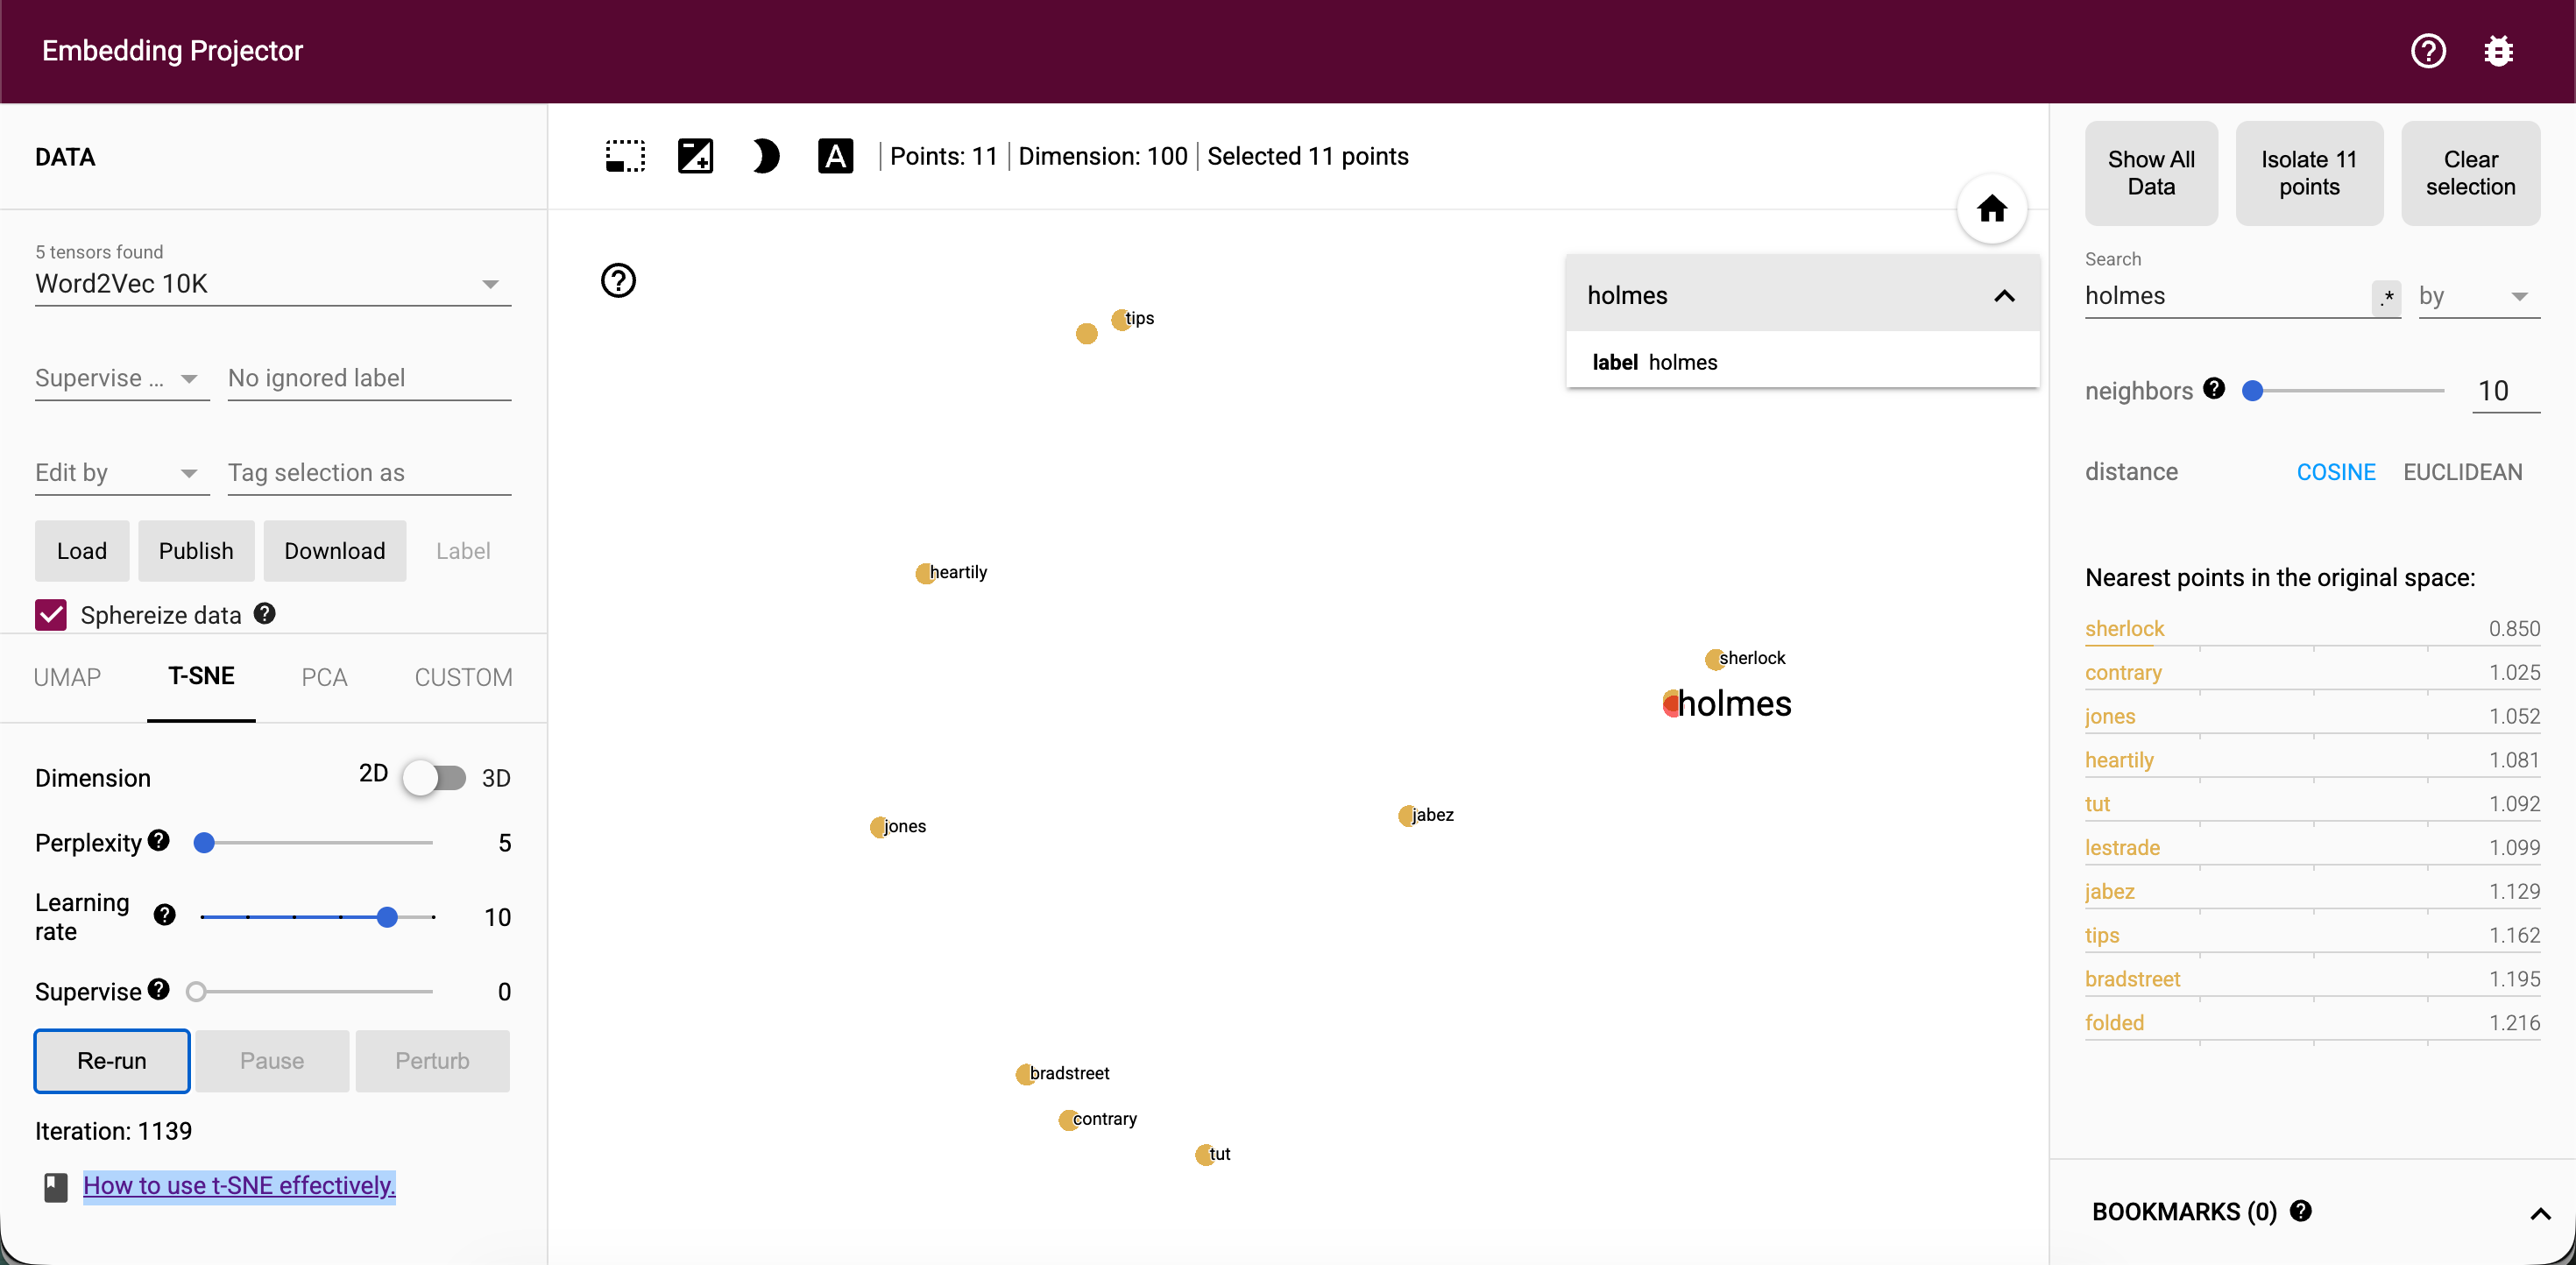

#### Grupo 2 — `said`



Los cinco vecinos más cercanos de `said` son 

- Todos verbos que introducen diálogo: `whispered`, `answered`, `cried`, `murmured`, `remarked`. 
- Es un grupo puramente sintáctico. Son intercambiables en la construcción `"...", <verbo> Holmes`. 
- Los otros vecinos son cosas que se dicen o a quién se le dice: el vocativo `watson`, las interjecciones `ah` y `tut`, y `funny`/`owe` de parlamentos frecuentes ("it's a funny thing", "I owe you"). 

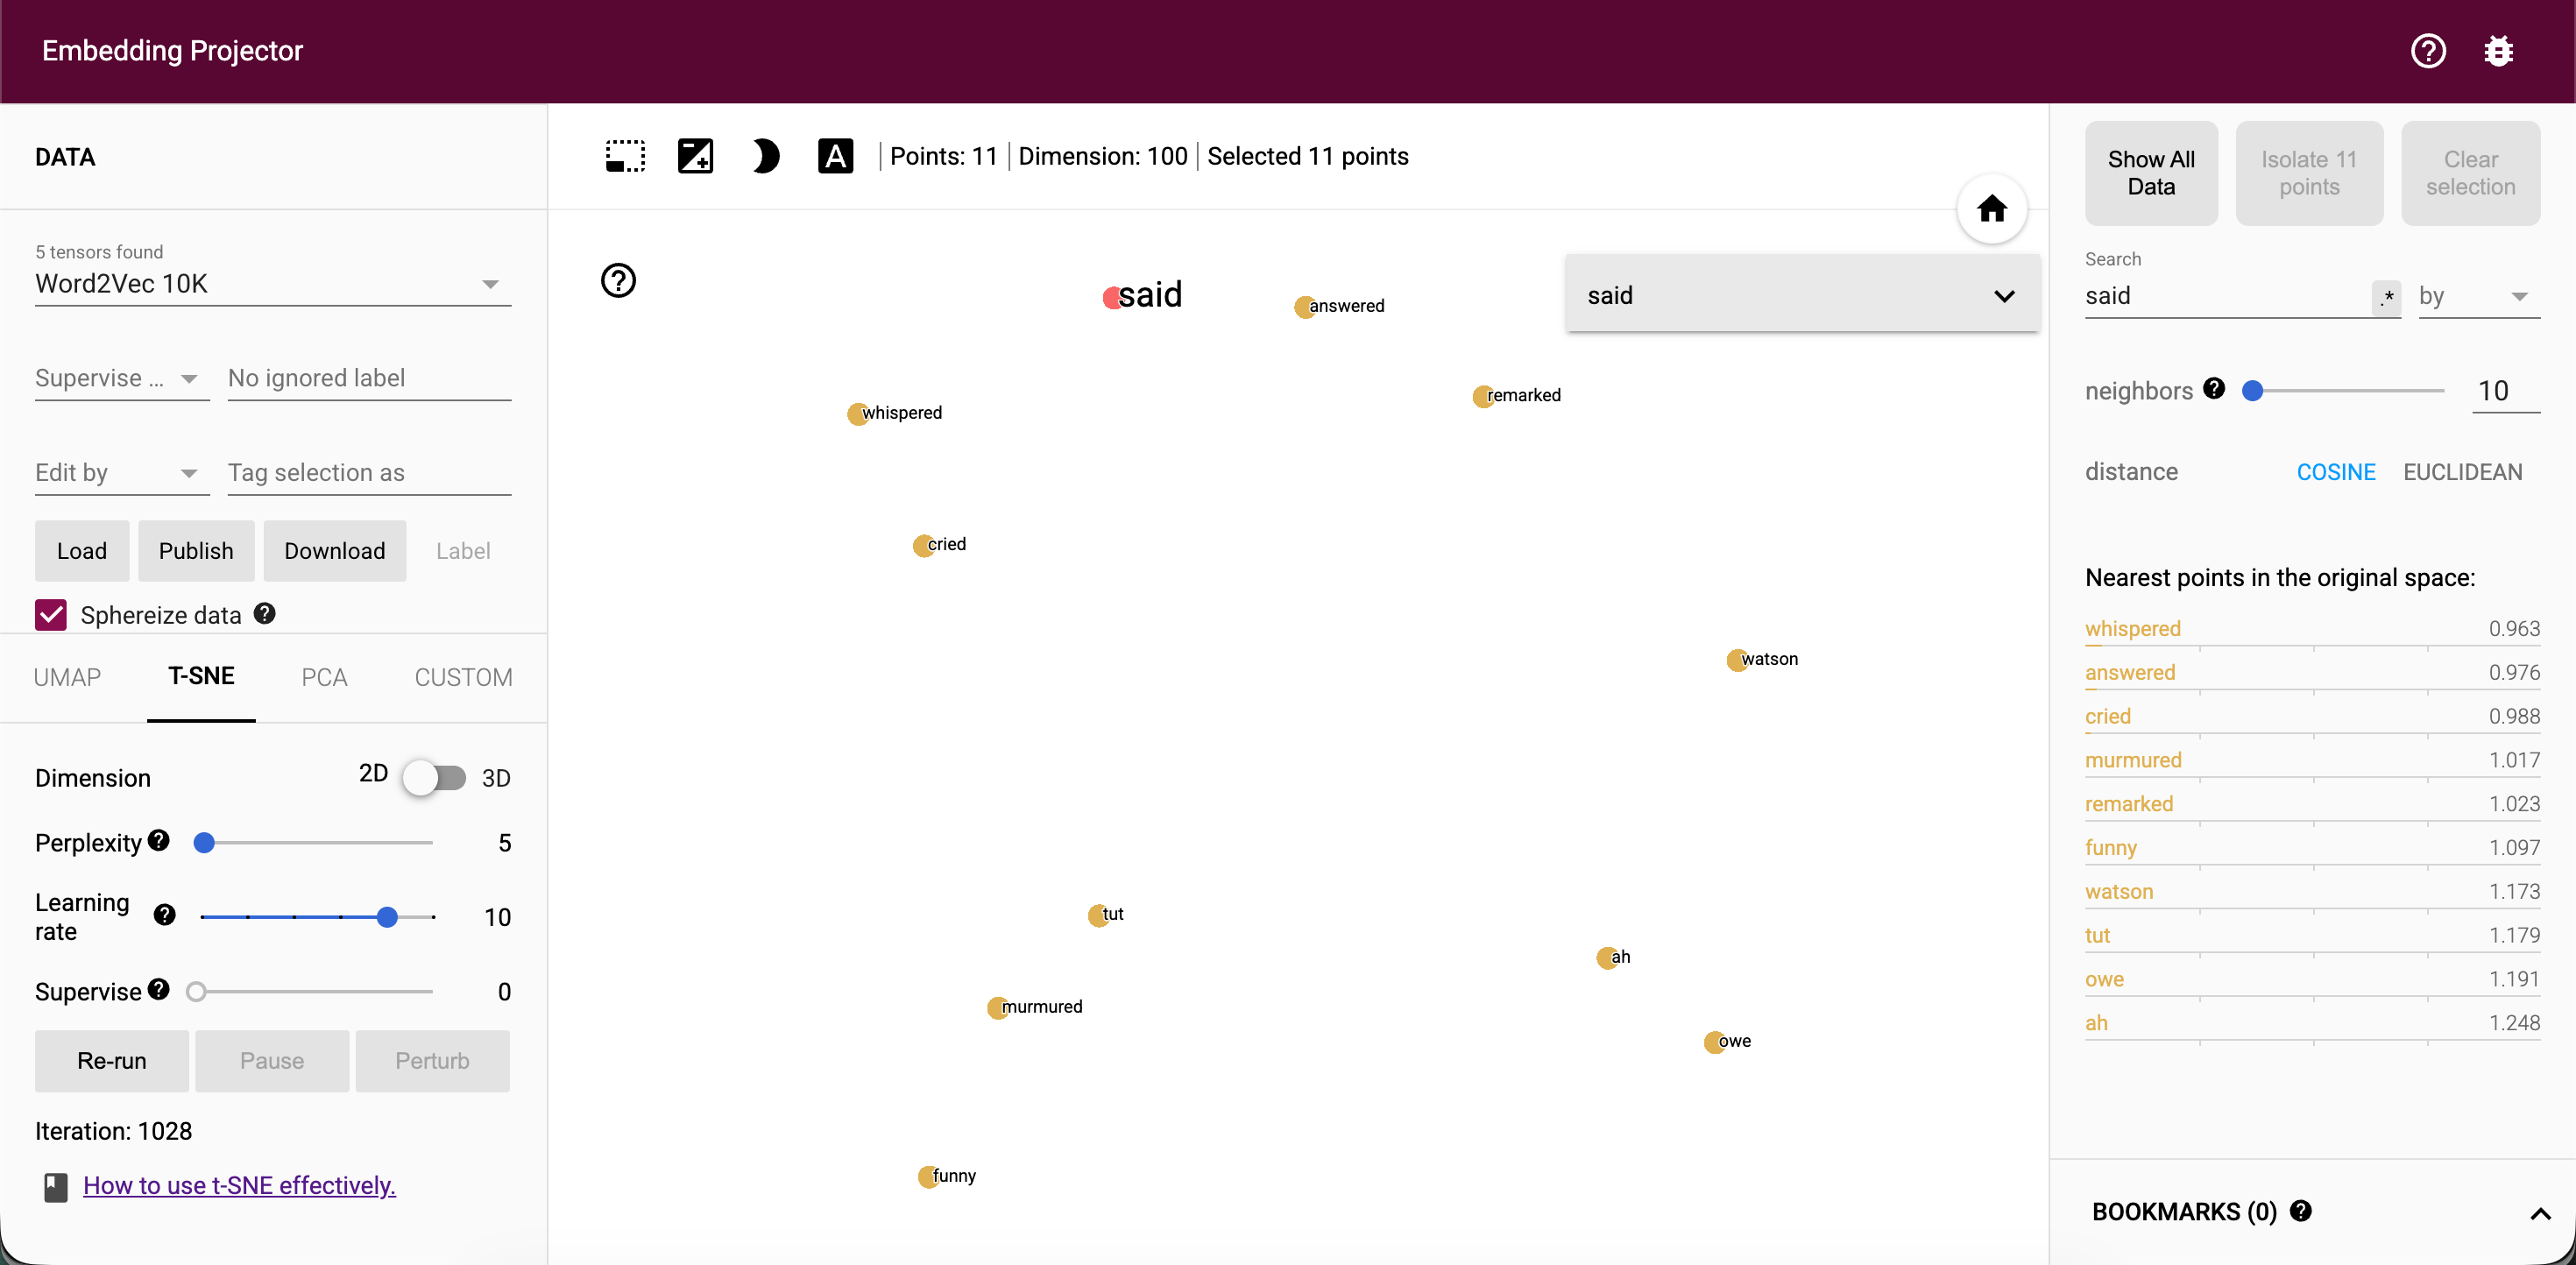

> Con este ejemplo se confirma lo que vimos en el Punto 2. Para `watson`: el modelo captura la estructura del diálogo, no el significado de las palabras.

#### Grupo 3 — `morning`

Este es un grupo muy limpio de expresiones temporales. Vemos los momentos del día `evening` y `afternoon`, `yesterday`, `early`, y la hora `eleven` / `o'clock`. 

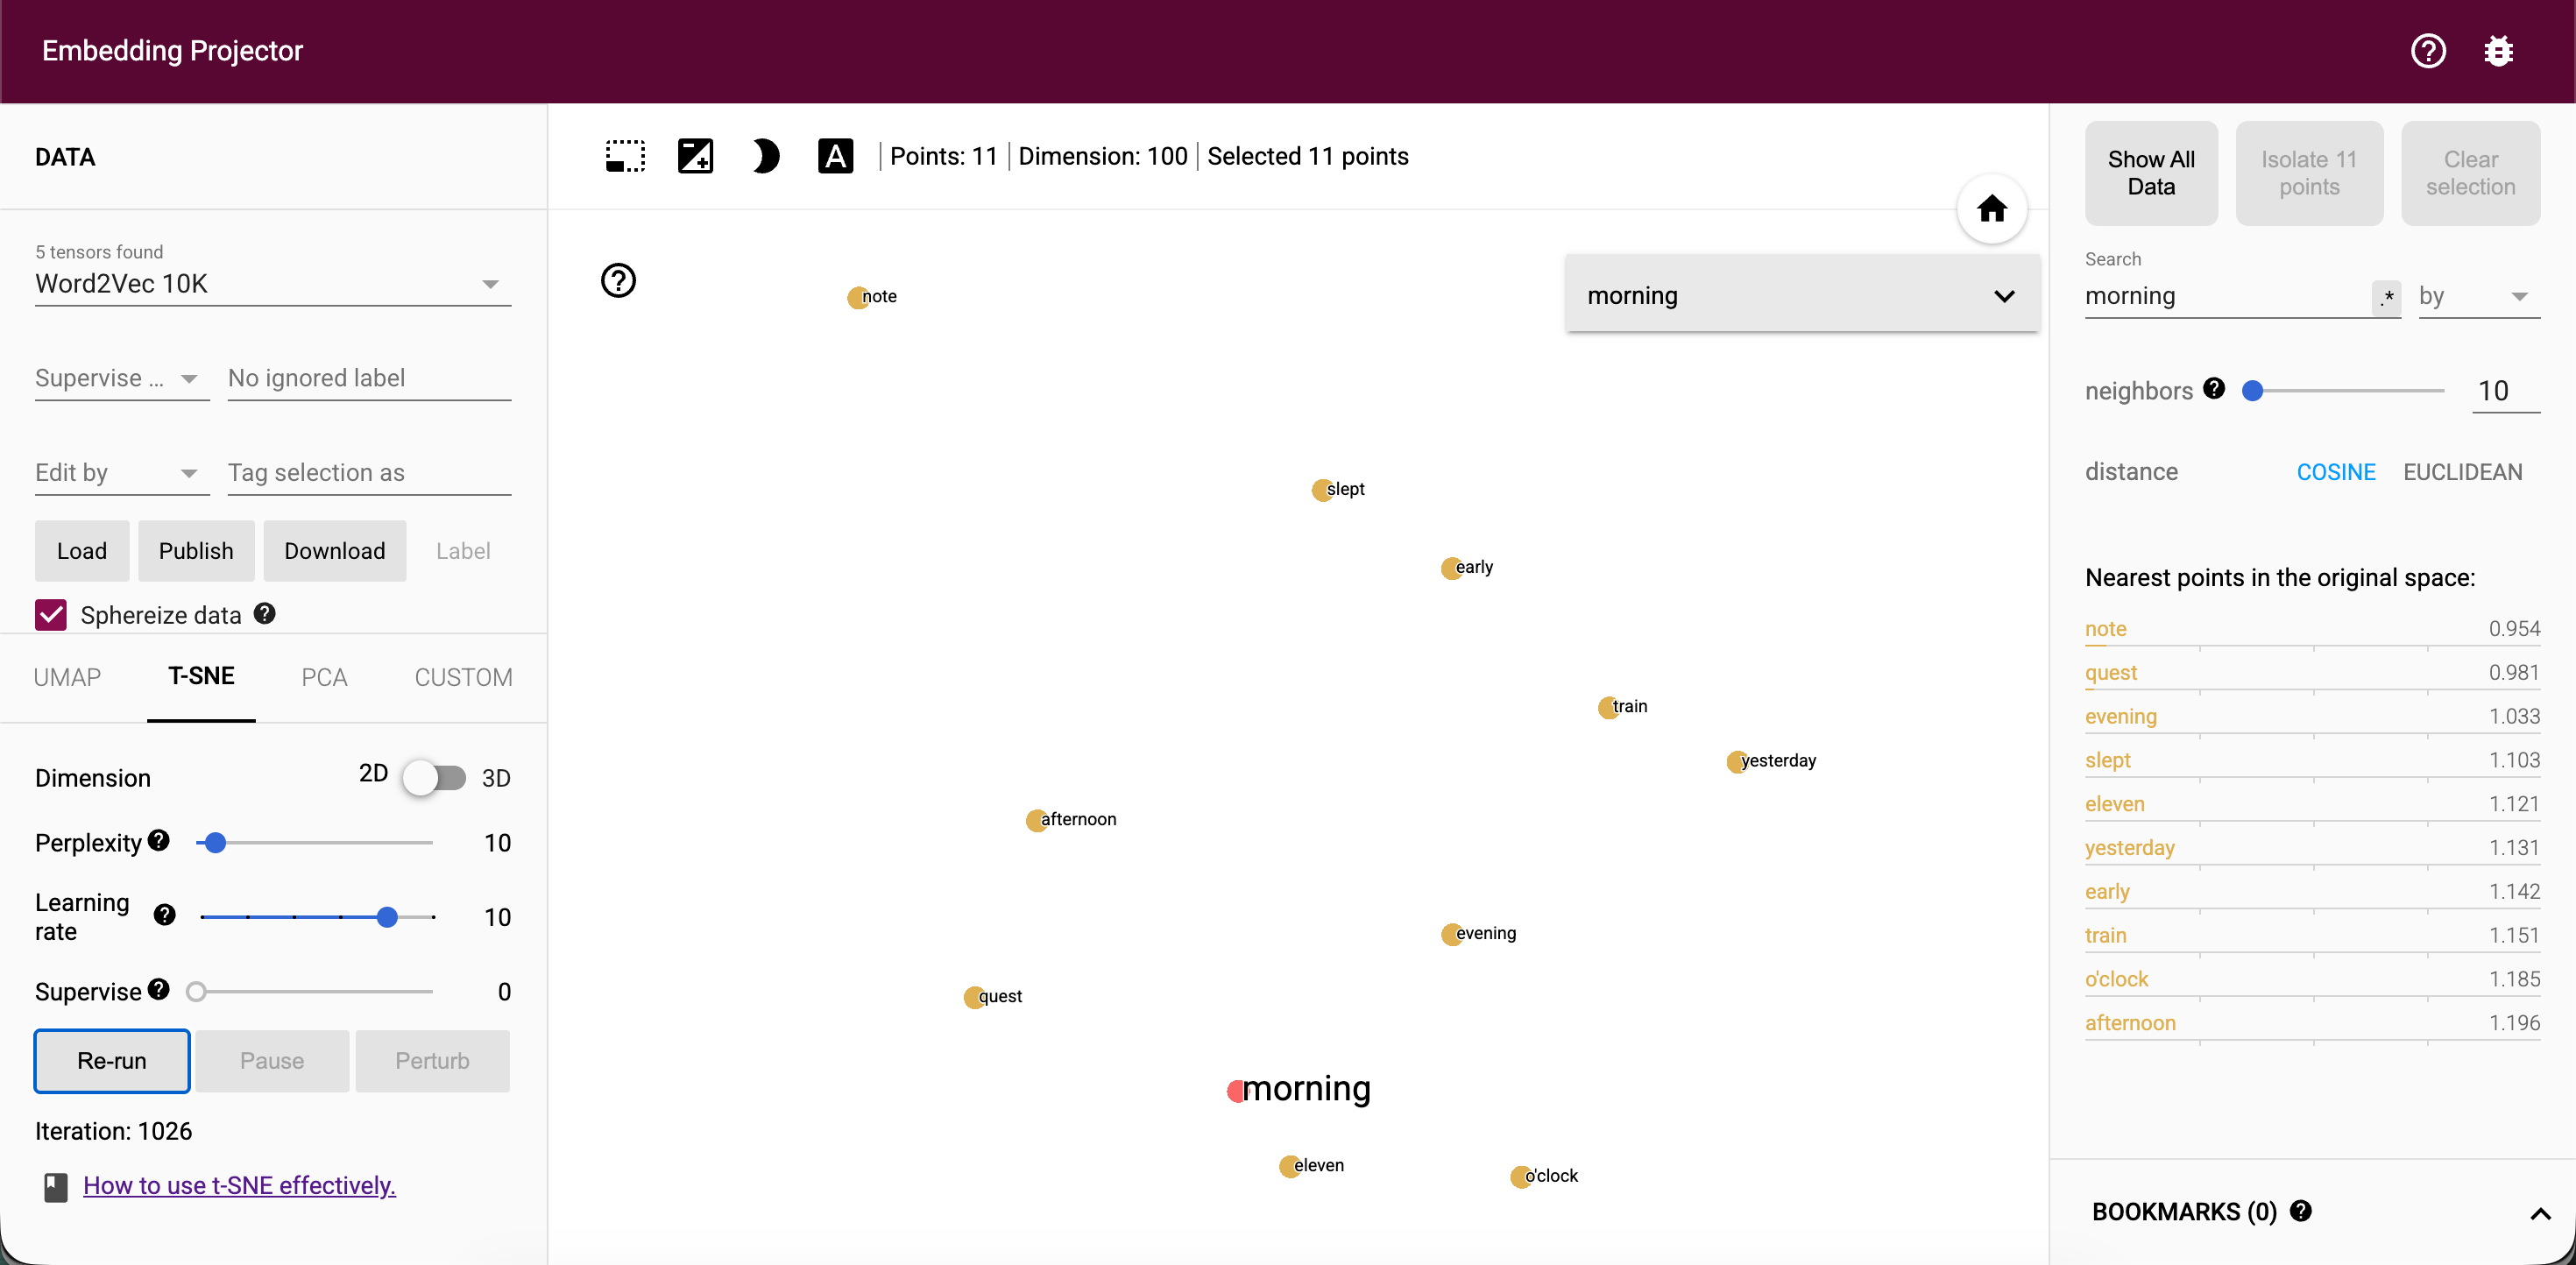

#### Grupo 4 — `door`

En este grupo se ven 
- Acciones y estados de una puerta: `locked`, `unlocked`, `opened`, `closed`, `key`
- Partes de la casa conectadas con la puerta: `hall`, `passage`, `stairs`, `panel` 
- Y el verbo de movimiento `dashed`. 

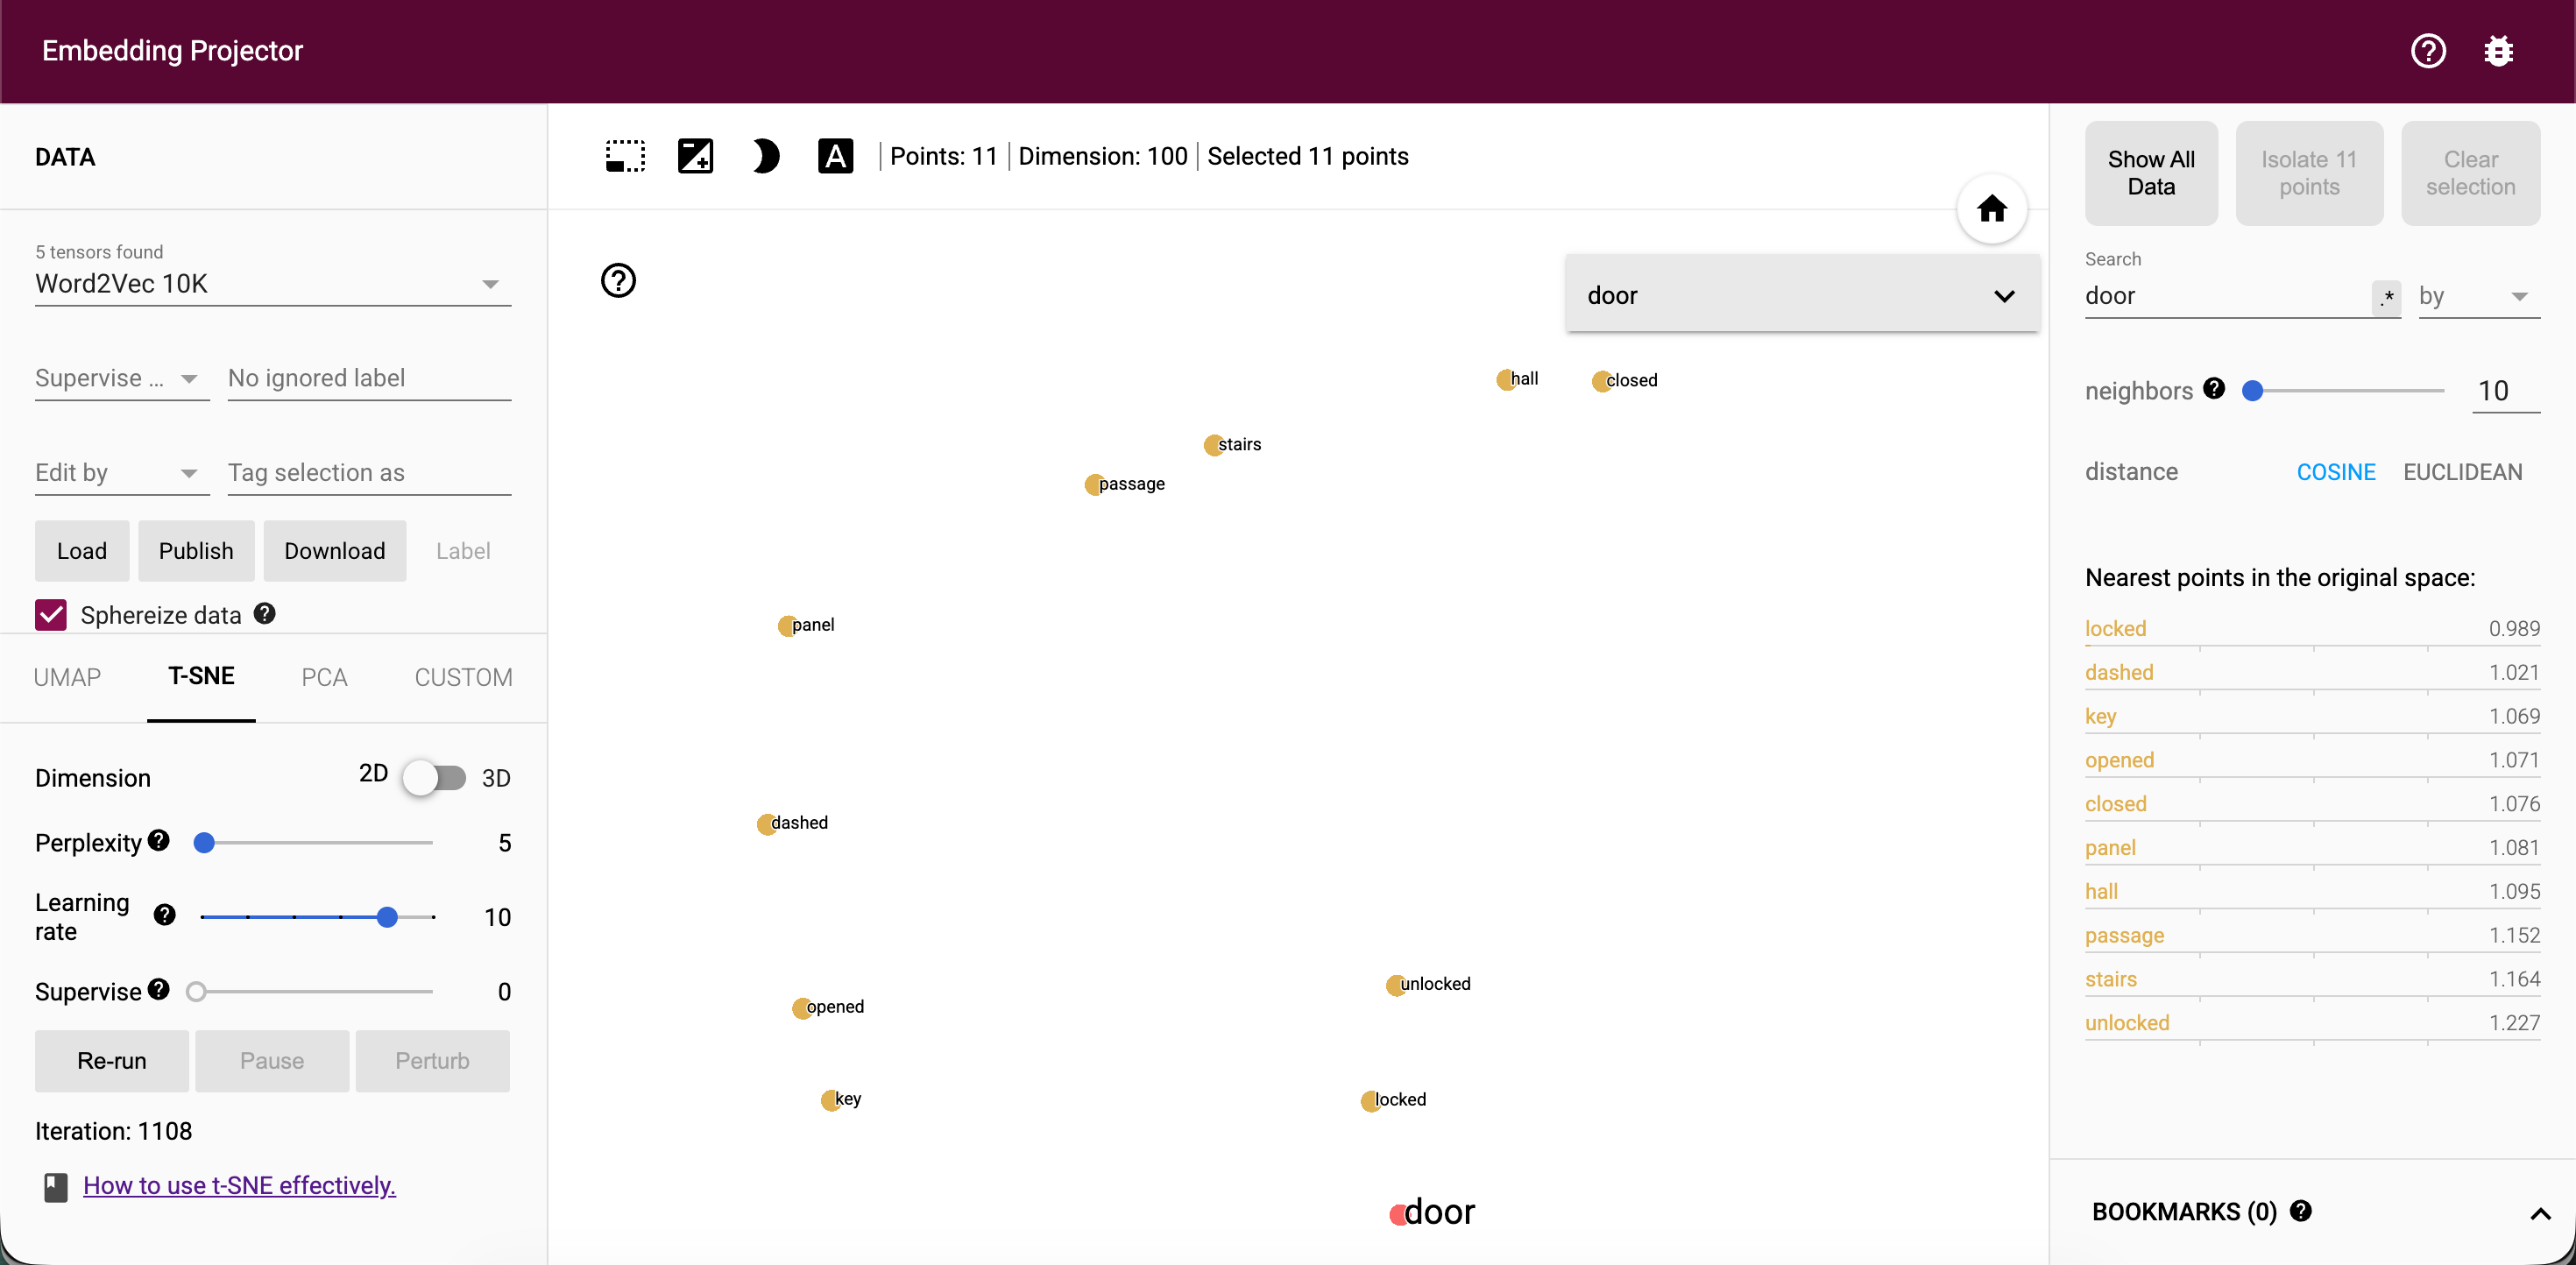

#### Grupo 5 — `letter`

Vemos que esta asociado a adjectivos u otros objetos descritos dentro de cartas

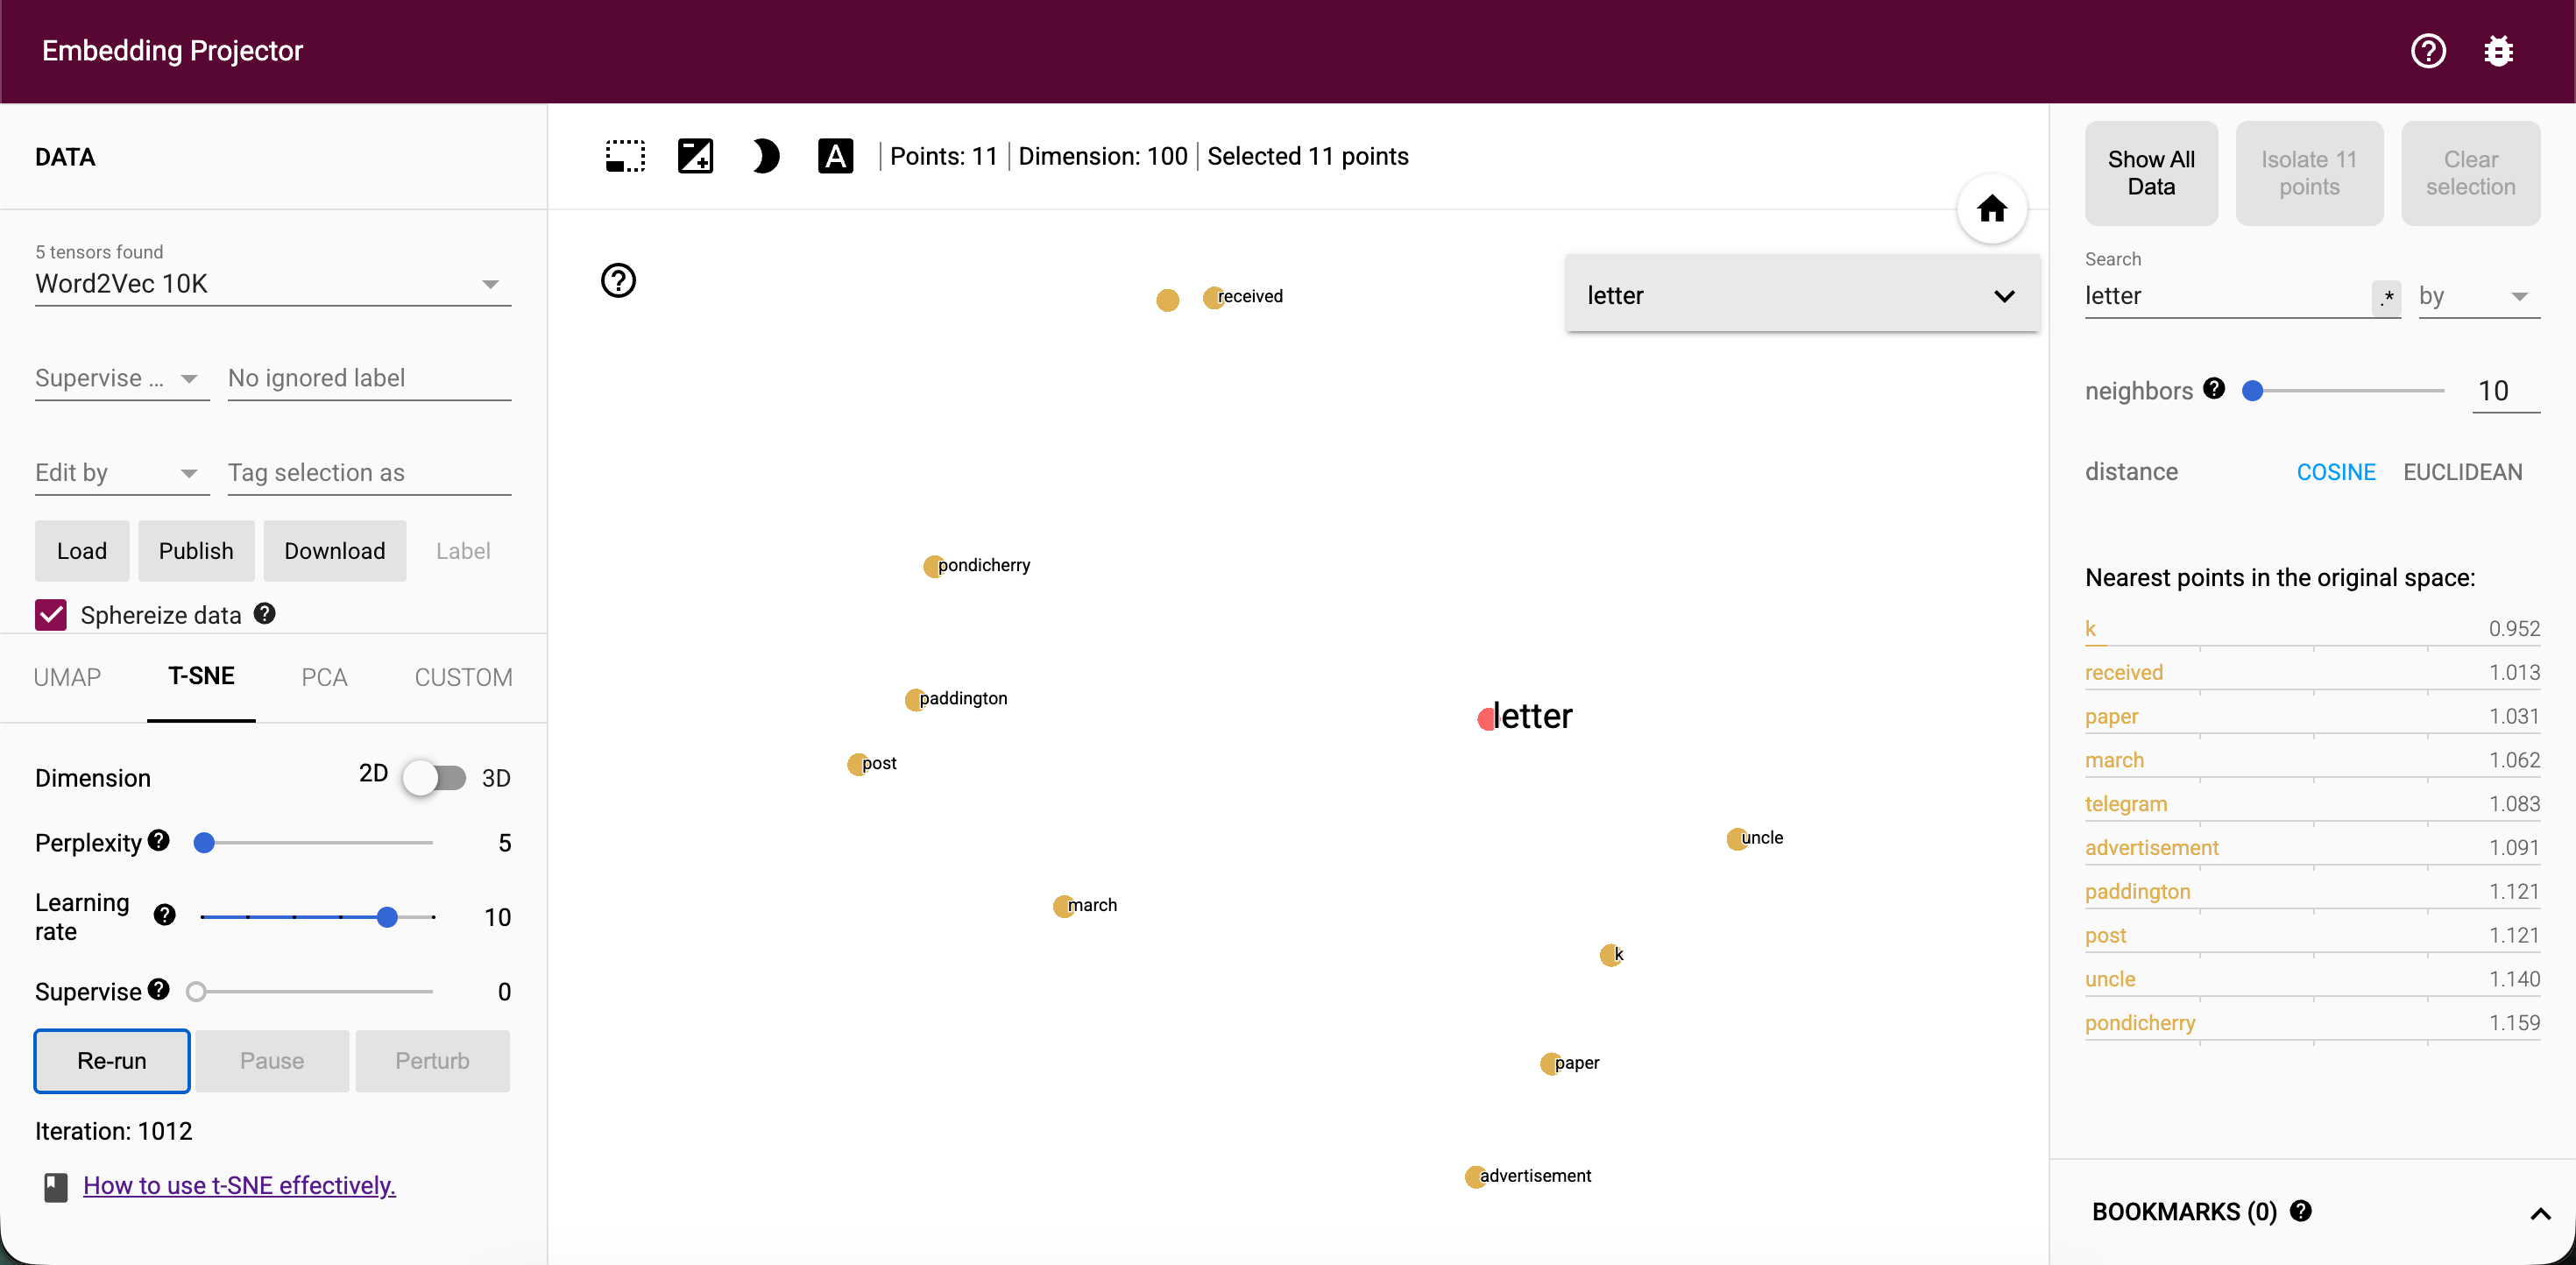

#### Grupo 6 — `street`: calles y lugares de Londres



Vemos que casi todos los vecinos son nombres propios que preceden a "Street" o forman direcciones: `baker` (Baker Street, el más cercano con diferencia), `leadenhall`, `park`, `victoria`, `bow`, `crown`, `lodgings`

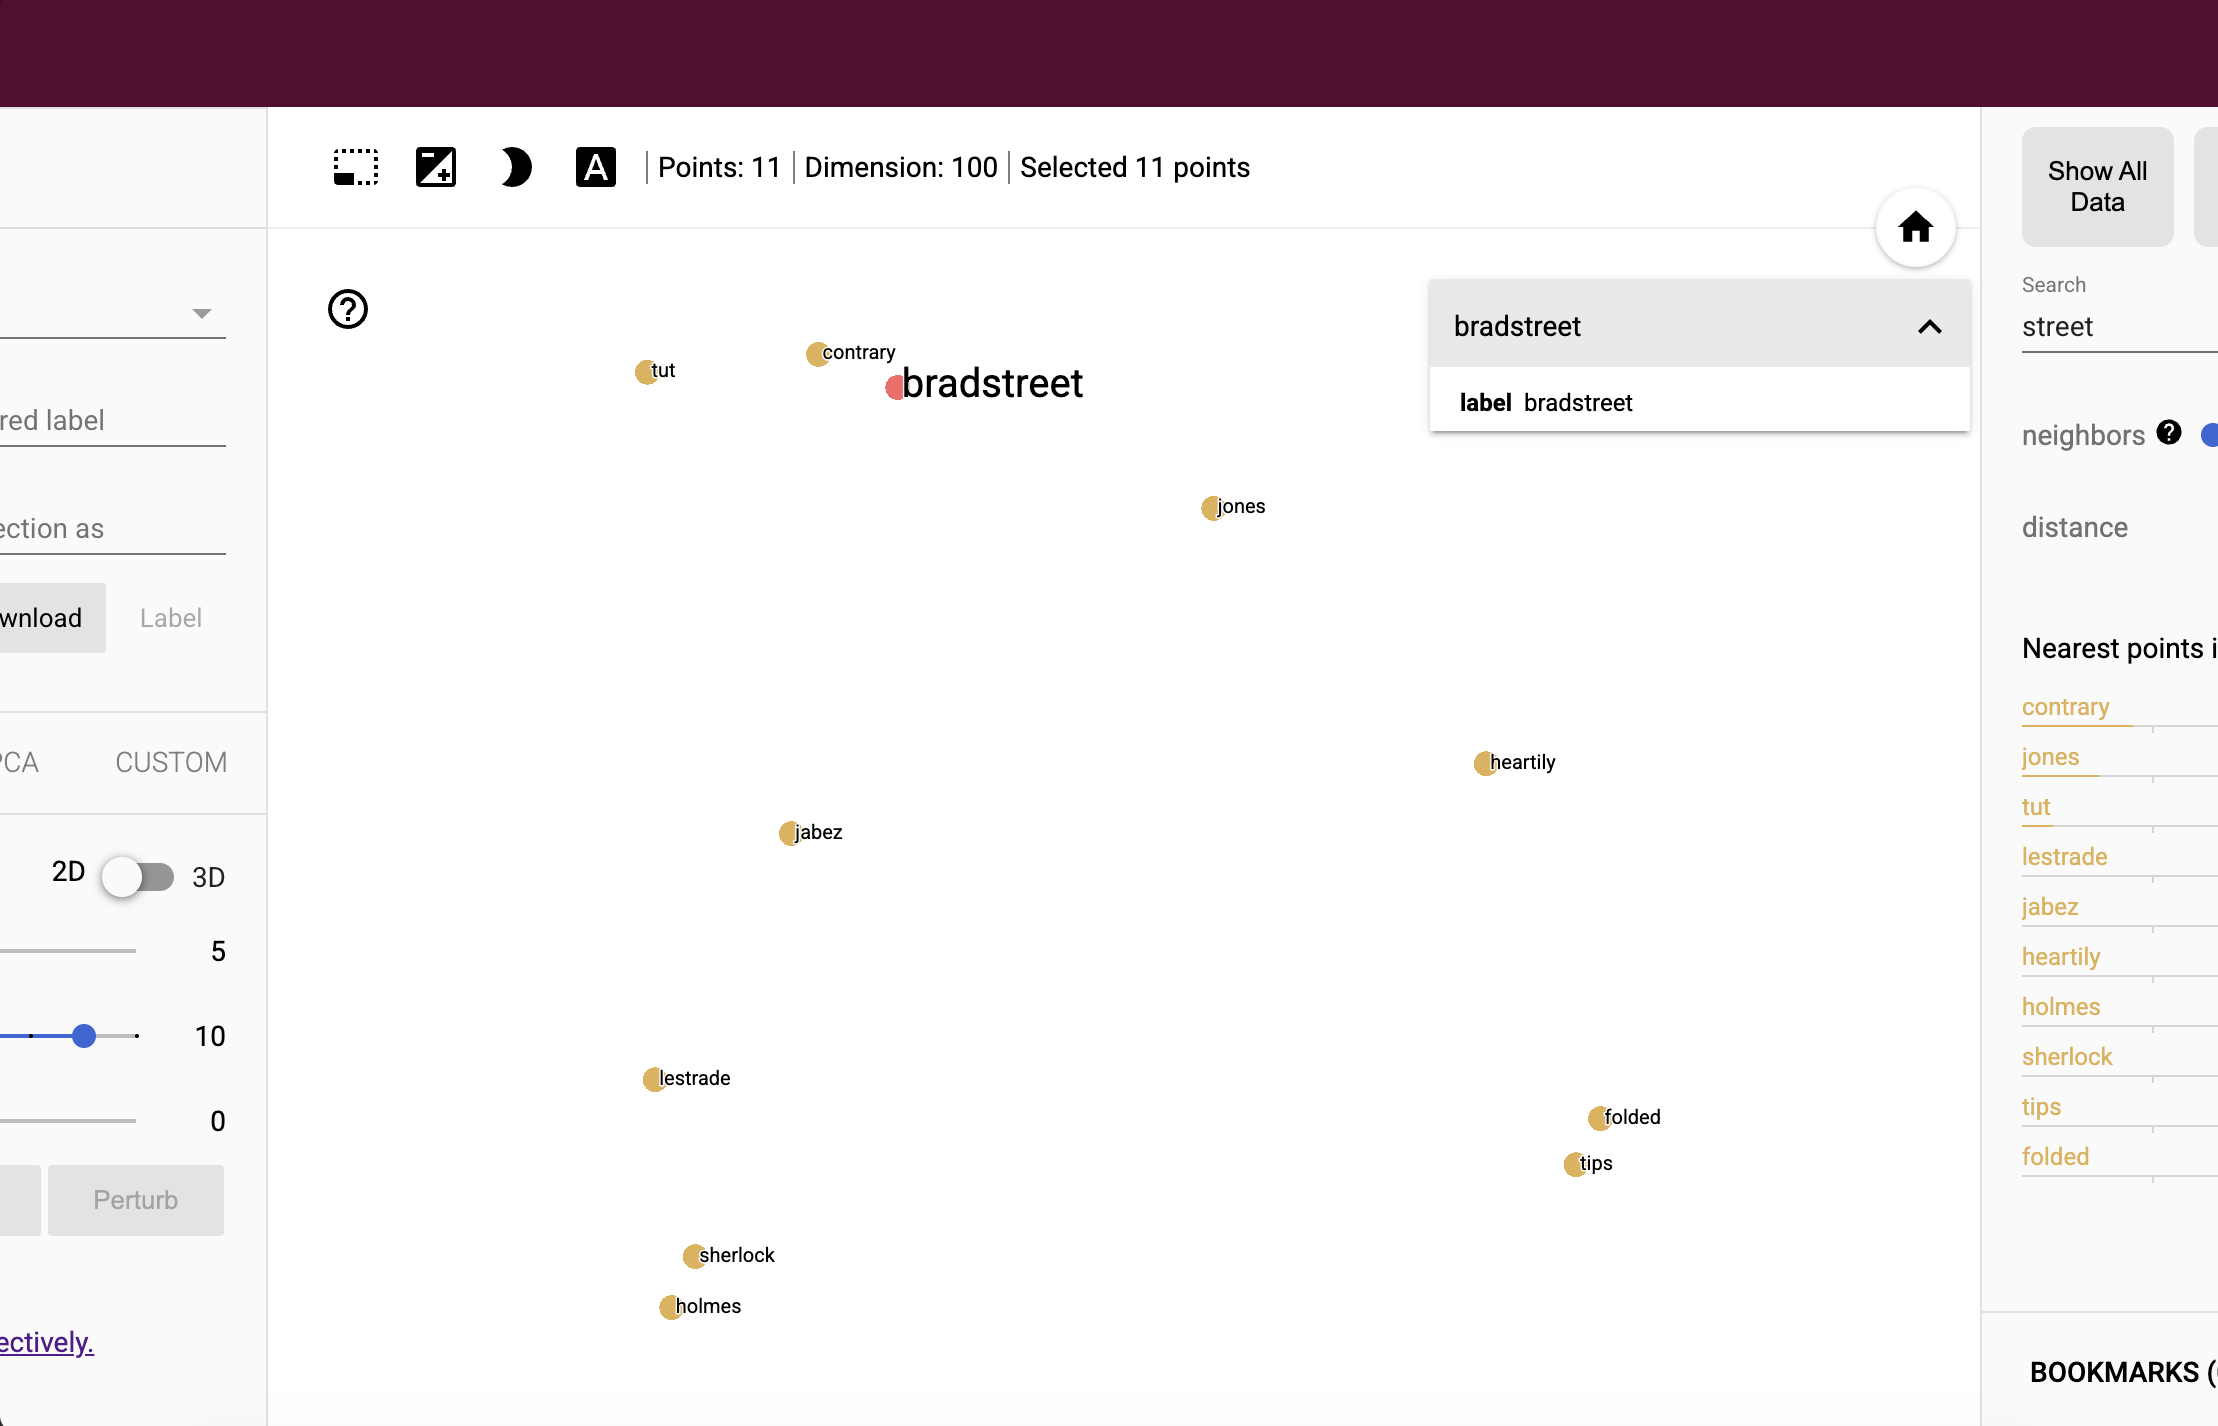